In [1]:
!git clone https://github.com/Hadeer-Mohamed-Eldesokeyy/TC_Project_New

Cloning into 'TC_Project_New'...
remote: Enumerating objects: 3904, done.
remote: Total 3904 (delta 0), reused 0 (delta 0), pack-reused 3904 (from 1)
Receiving objects: 100% (3904/3904), 322.44 MiB | 28.91 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Updating files: 100% (3550/3550), done.


In [2]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.0 MB/s eta 0:00:00


In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import models, transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from PIL import Image
import random
import pydicom

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Data Preprocessiong

In [2]:
# loading data (augmented and original) for tc and normal into one dataset with labels(tc or normal) but spliting it into train and test
def load_data(tc_aug_path, tc_sim_path, normal_path):
  data = []
  labels = []
  classes = [] # To store 'early', 'late', or 'normal' stage

  # Load TC Augmented images (considered 'late' stage)
  for root, _, files in os.walk(tc_aug_path):
      for tc_file in files:
          if tc_file.lower().endswith(('.png', '.jpg', '.jpeg', '.dcm')): # Added file extension check
              img_path = os.path.join(root, tc_file)
              try:
                  # Attempt to load image, handling DICOM
                  if tc_file.lower().endswith('.dcm'):
                      ds = pydicom.dcmread(img_path)
                      img = ds.pixel_array
                      img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
                      img = img.astype(np.uint8)
                      img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # Convert DICOM (often grayscale) to RGB
                  else:
                      img = cv2.imread(img_path, cv2.IMREAD_COLOR) # Load as color image
                      if img is not None and len(img.shape) == 2: # Check if loaded as grayscale unexpectedly
                           img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)


                  if img is not None: # Check if image was loaded successfully
                      img = cv2.resize(img, (224, 224)) # Resize to 224x224
                      img = img.astype('float32') / 255.0
                      data.append(img)
                      labels.append('tc')
                      classes.append('late') # Augmented TC images are considered 'late' stage
                  else:
                      print(f"Warning: Could not load image {img_path}") # Print warning for failed loads
              except Exception as e:
                  print(f"Error loading image {img_path}: {e}") # Catch other potential errors

  # Load Simulated TC images

  if os.path.exists(tc_sim_path):
      for sim_file in os.listdir(tc_sim_path):
          if sim_file.lower().endswith(('.png', '.jpg', '.jpeg')): # Assuming simulated are png/jpg
              img_path = os.path.join(tc_sim_path, sim_file)
              try:
                  img = cv2.imread(img_path, cv2.IMREAD_COLOR)
                  if img is not None and len(img.shape) == 2:
                      img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

                  if img is not None:
                      img = cv2.resize(img, (224, 224)) # Resize to 224x224
                      img = img.astype('float32') / 255.0
                      data.append(img)
                      labels.append('tc')
                      classes.append('early') # Add the stage ('early') to classes
                  else:
                      print(f"Warning: Could not load simulated image {img_path}")
              except Exception as e:
                  print(f"Error loading simulated image {img_path}: {e}")


  # Load Normal images
  for normal_file in os.listdir(normal_path):
      if normal_file.lower().endswith(('.png', '.jpg', '.jpeg', '.dcm')): # Added file extension check
          img_path = os.path.join(normal_path, normal_file)
          try:
              # Attempt to load image, handling DICOM
              if normal_file.lower().endswith('.dcm'):
                  ds = pydicom.dcmread(img_path)
                  img = ds.pixel_array
                  img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
                  img = img.astype(np.uint8)
                  img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # Convert DICOM (often grayscale) to RGB
              else:
                  img = cv2.imread(img_path, cv2.IMREAD_COLOR) # Load as color image
                  if img is not None and len(img.shape) == 2: # Check if loaded as grayscale unexpectedly
                       img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)


              if img is not None: # Check if image was loaded successfully
                  img = cv2.resize(img, (224, 224)) # Resize to 224x224
                  img = img.astype('float32') / 255.0
                  data.append(img)
                  labels.append('normal')
                  classes.append('normal') # Normal images are 'normal' stage
              else:
                  print(f"Warning: Could not load image {img_path}") # Print warning for failed loads
          except Exception as e:
              print(f"Error loading image {img_path}: {e}") # Catch other potential errors


  data = np.array(data)
  labels = np.array(labels)
  classes = np.array(classes)
  return data, labels, classes

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:


tc_augmented = '/content/TC_Project_New/dataset/augmented'
tc_simulated = '/content/TC_Project_New/dataset/lesion_simulated/early'
normal = '/content/TC_Project_New/dataset/raw/normal'
data , labels, classes = load_data(tc_augmented,tc_simulated, normal)

In [4]:
data.shape

(2962, 224, 224, 3)

In [5]:
import numpy as np

# Count the occurrences of each unique label
unique_labels, counts = np.unique(labels, return_counts=True)

# Print the counts
for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count} occurrences")

Label normal: 2218 occurrences
Label tc: 744 occurrences


In [6]:
classes

array(['late', 'late', 'late', ..., 'normal', 'normal', 'normal'],
      dtype='<U6')

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)


In [8]:
le.classes_

array(['normal', 'tc'], dtype='<U6')

In [9]:
le2 = LabelEncoder()
classes = le2.fit_transform(classes)

In [10]:
le2.classes_

array(['early', 'late', 'normal'], dtype='<U6')

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=42, stratify=labels,shuffle=True)

In [12]:
y_train

array([1, 0, 0, ..., 0, 0, 1])

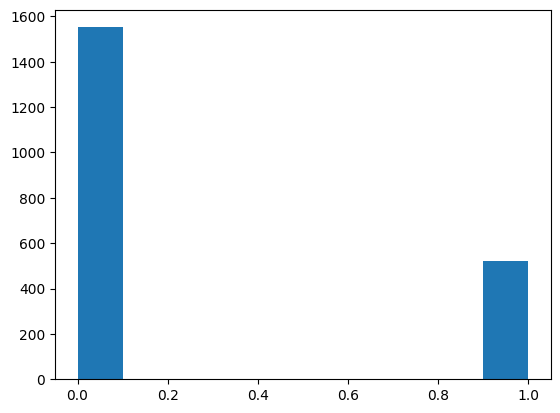

In [13]:
import matplotlib.pyplot as plt
plt.hist(y_train)
plt.show()

# First Model (Classifies Normal or TC)

In [22]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
import tensorflow as tf


In [23]:


resnet_model = Sequential()
resnet_model.add(ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3)))
resnet_model.add(GlobalAveragePooling2D())
resnet_model.add(Dense(256, activation='relu'))
resnet_model.add(BatchNormalization()) # Added Batch Normalization
resnet_model.add(Dropout(0.6)) # Increased dropout
resnet_model.add(Dense(128, activation='relu')) # Added another dense layer
resnet_model.add(BatchNormalization()) # Added Batch Normalization
resnet_model.add(Dropout(0.6)) # Added another dropout layer
resnet_model.add(Dense(1, activation='sigmoid'))

In [24]:
resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,146,817 (92.11 MB)

 Trainable params: 24,092,929 (91.91 MB)

 Non-trainable params: 53,888 (210.50 KB)

In [25]:
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15)
checkpoint = tf.keras.callbacks.ModelCheckpoint('/content/drive/MyDrive/TC_Project/models/binary_classifier/best_model.keras', monitor='val_loss', save_best_only=True)

In [27]:
resnet_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
hist2 = resnet_model.fit(X_train, y_train, epochs=50, validation_split=0.2,callbacks=[early_stop,checkpoint],batch_size=20,class_weight = {0: 1.0, 1: 5})

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 134s 741ms/step - accuracy: 0.5035 - loss: 2.2533 - val_accuracy: 0.2771 - val_loss: 1.3577
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 19s 222ms/step - accuracy: 0.5690 - loss: 1.8454 - val_accuracy: 0.2771 - val_loss: 1.3807
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 18s 218ms/step - accuracy: 0.6116 - loss: 1.5395 - val_accuracy: 0.2771 - val_loss: 1.9897
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step - accuracy: 0.5954 - loss: 1.4642 - val_accuracy: 0.2771 - val_loss: 2.3000
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 216ms/step - accuracy: 0.6176 - loss: 1.5271 - val_accuracy: 0.2771 - val_loss: 3.1652
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 216ms/step - accuracy: 0.6688 - loss: 1.1086 - val_accuracy: 0.2771 - val_loss: 3.3713
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 18s 215ms/step - accuracy: 0.7007 - loss: 0.9979 - val_accuracy: 0.2771 - val_loss: 4.0351
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step - accuracy: 0.6875 - loss: 0.9311 - val_acc

In [28]:
result = resnet_model.evaluate(X_test, y_test)
print("Test Loss:", result[0])
print("Test Accuracy:", result[1])

28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 246ms/step - accuracy: 0.9078 - loss: 0.3369
Test Loss: 0.32780277729034424
Test Accuracy: 0.9032620787620544


In [30]:
y_pred = resnet_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step


In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       666
           1       0.78      0.85      0.82       223

    accuracy                           0.90       889
   macro avg       0.87      0.89      0.87       889
weighted avg       0.91      0.90      0.90       889

[[613  53]
 [ 33 190]]


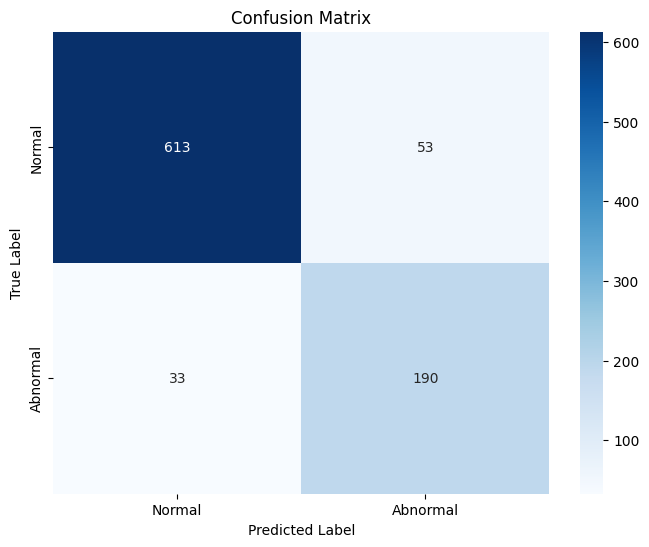

In [32]:
class_names = ['Normal', 'Abnormal']
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()